In [1]:
!wget --no-check-certificate https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip -O /content/cats_and_dogs_filtered.zip

!unzip -q /content/cats_and_dogs_filtered.zip -d /content/

--2026-04-20 05:16:42--  https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.217.194.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/content/cats_and_dogs_filtered.zip’

/content/cats_and_d 100%[===================>]  65.43M  17.0MB/s    in 5.4s    

2026-04-20 05:16:48 (12.2 MB/s) - ‘/content/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cats_and_dogs_filtered.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

##Implementing Feature Extraction with test and train data

In [5]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [6]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [8]:
conv_base.trainable = False # Freezing the weights and bias of the CNN architecture

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_and_dogs_filtered/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_and_dogs_filtered/validation',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [11]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 262ms/step - accuracy: 0.8155 - loss: 0.4545 - val_accuracy: 0.8740 - val_loss: 0.2725
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9190 - loss: 0.2021 - val_accuracy: 0.8870 - val_loss: 0.2611
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9555 - loss: 0.1220 - val_accuracy: 0.8900 - val_loss: 0.2618
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.9695 - loss: 0.0842 - val_accuracy: 0.8980 - val_loss: 0.2581
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9840 - loss: 0.0553 - val_accuracy: 0.8880 - val_loss: 0.2786
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9955 - loss: 0.0330 - val_accuracy: 0.8980 - val_loss: 0.2889
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 0.9000 - val_loss: 0.2976
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy:

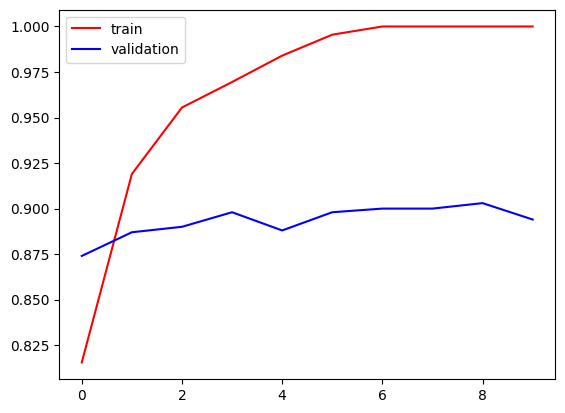

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

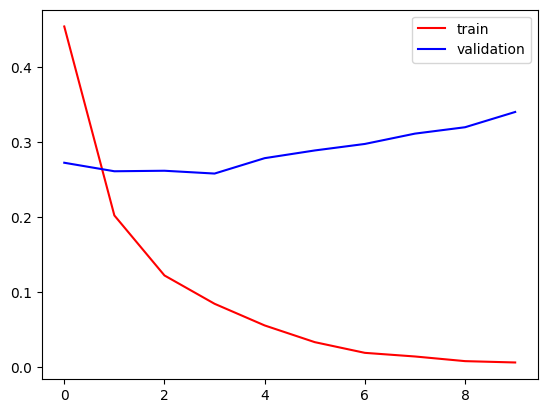

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

##Implementing Feature Extraction with test and train data by Generating Synthetic Data

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [17]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/cats_and_dogs_filtered/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/cats_and_dogs_filtered/validation',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [18]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step - accuracy: 0.9145 - loss: 0.2344 - val_accuracy: 0.8850 - val_loss: 0.2837
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.9320 - loss: 0.1829 - val_accuracy: 0.8860 - val_loss: 0.2876
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - accuracy: 0.9380 - loss: 0.1579 - val_accuracy: 0.8930 - val_loss: 0.2580
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.9565 - loss: 0.1186 - val_accuracy: 0.8930 - val_loss: 0.2781
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.9580 - loss: 0.1078 - val_accuracy: 0.8830 - val_loss: 0.3470
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - accuracy: 0.9575 - loss: 0.1170 - val_accuracy: 0.8700 - val_loss: 0.3743
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.9465 - loss: 0.1190 - val_accuracy: 0.9010 - val_loss: 0.2692
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step - accuracy: 0.9530 - loss: 0.1036 - val_accu

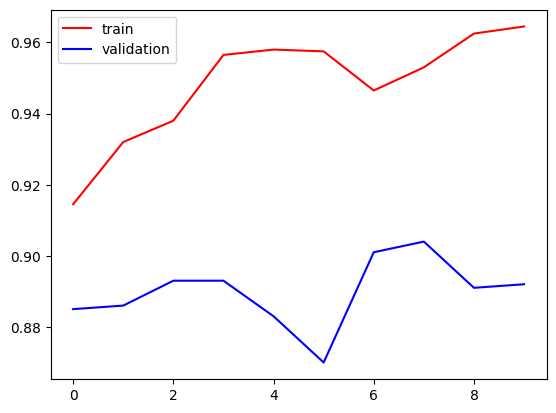

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

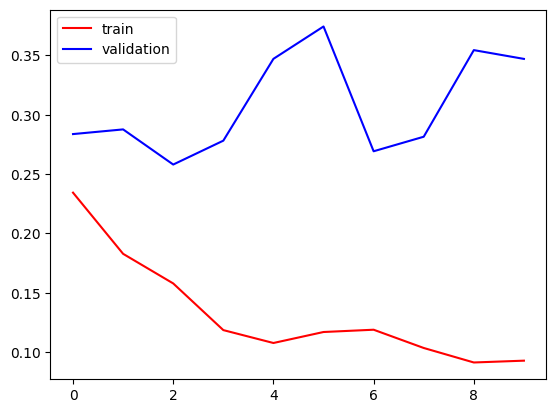

In [21]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

##Implementing Fine Tuning with test and train data

In [22]:
# Defreezing the last (Conv_block_5)
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [23]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [24]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [25]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_and_dogs_filtered/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_and_dogs_filtered/validation',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [26]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [27]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

In [28]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.8225 - loss: 0.4370 - val_accuracy: 0.8730 - val_loss: 0.3101
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9145 - loss: 0.2322 - val_accuracy: 0.8860 - val_loss: 0.2745
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9405 - loss: 0.1634 - val_accuracy: 0.9090 - val_loss: 0.2210
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9620 - loss: 0.1157 - val_accuracy: 0.9090 - val_loss: 0.2119
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.9710 - loss: 0.0863 - val_accuracy: 0.9140 - val_loss: 0.2074
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.9860 - loss: 0.0634 - val_accuracy: 0.9060 - val_loss: 0.2166
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9925 - loss: 0.0423 - val_accuracy: 0.9280 - val_loss: 0.1982
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9960 - loss: 0.0311 - val_accu

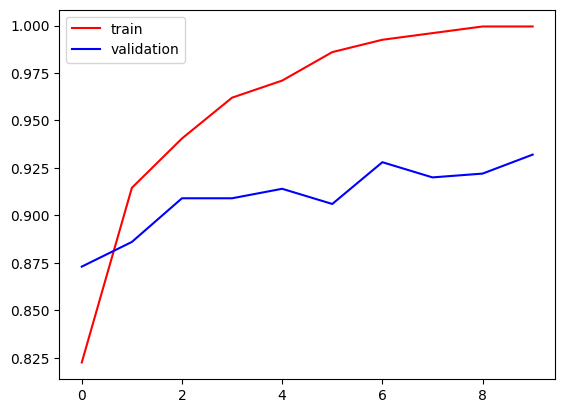

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

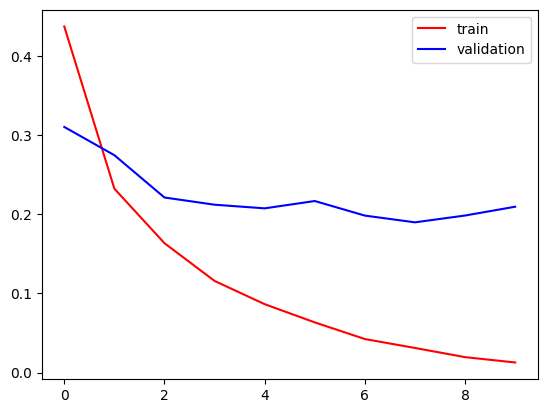

In [30]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

##Implementing Fine Tuning with test and train data by Generating Synthetic Data

In [31]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [32]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./25)

train_generator = train_datagen.flow_from_directory(
        '/content/cats_and_dogs_filtered/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

test_generator = test_datagen.flow_from_directory(
        '/content/cats_and_dogs_filtered/validation',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [33]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

In [34]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 378ms/step - accuracy: 0.8715 - loss: 0.2972 - val_accuracy: 0.9090 - val_loss: 0.2176
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.9340 - loss: 0.1772 - val_accuracy: 0.9080 - val_loss: 0.2210
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.9375 - loss: 0.1578 - val_accuracy: 0.9130 - val_loss: 0.1900
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step - accuracy: 0.9485 - loss: 0.1322 - val_accuracy: 0.9210 - val_loss: 0.1797
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.9620 - loss: 0.1113 - val_accuracy: 0.9270 - val_loss: 0.1863
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.9630 - loss: 0.1004 - val_accuracy: 0.9230 - val_loss: 0.1829
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.9670 - loss: 0.0840 - val_accuracy: 0.9120 - val_loss: 0.2121
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.9745 - loss: 0.0797 - val_accu

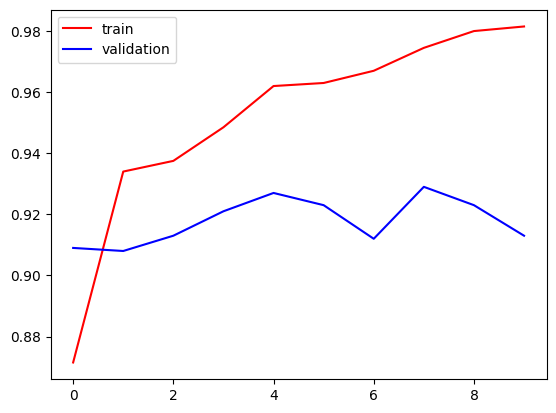

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

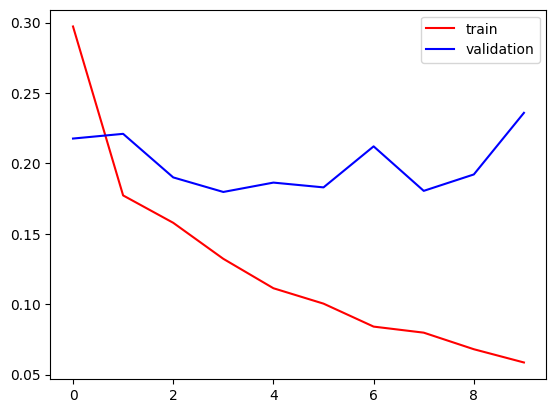

In [36]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

## Final Evaluation of the Best Model (Fine-Tuning + Augmentation)

The cells below are executed **after the FT+Aug `model.fit(...)` above completes**.
They build a fresh, un-shuffled validation generator, run predictions, and
produce: confusion matrix (matplotlib heatmap), per-class precision / recall /
F1, specificity, macro-F1, accuracy, ROC curve, and ROC-AUC. All numbers are
also saved to `real_metrics.json` so they can be quoted verbatim in the
report and slide deck.


Found 1000 images belonging to 2 classes.
class_indices: {'cats': 0, 'dogs': 1}

Confusion matrix (rows = true, cols = predicted)
                 pred:cat  pred:dog
  true:cat           430       70
  true:dog            17      483

=== Classification report ===
              precision    recall  f1-score   support

         cat     0.9620    0.8600    0.9081       500
         dog     0.8734    0.9660    0.9174       500

    accuracy                         0.9130      1000
   macro avg     0.9177    0.9130    0.9128      1000
weighted avg     0.9177    0.9130    0.9128      1000

Accuracy        : 0.9130
Macro F1        : 0.9128
Precision (cat) : 0.9620   Precision (dog) : 0.8734
Recall    (cat) : 0.8600   Recall    (dog) : 0.9660
F1        (cat) : 0.9081   F1        (dog) : 0.9174
Specificity (cat as neg) : 0.8600
Sensitivity (dog as pos) : 0.9660
ROC AUC                  : 0.9827


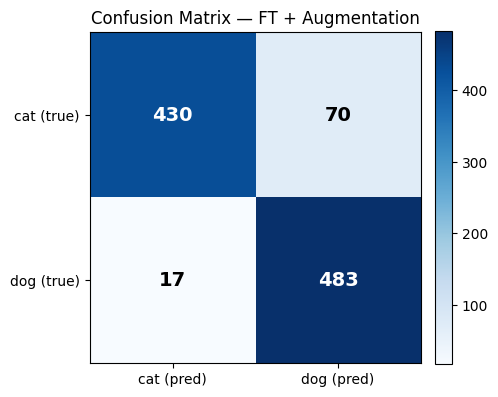

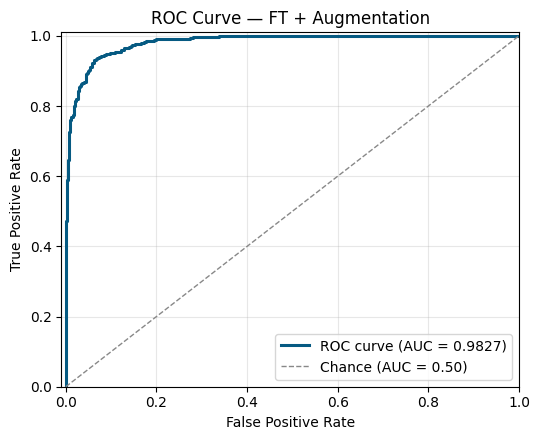

In [37]:
# === Final evaluation of the best model (FT + Augmentation) ===
# Run this cell AFTER the last model.fit() in the Fine-Tuning + Augmentation section.

import os, json, numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score,
)

# 1) Fresh validation generator (shuffle=False so predictions line up with labels).
#    We use a dedicated ImageDataGenerator(rescale=1./255) — do NOT reuse
#    `test_datagen` from an earlier cell in case it had a typo.
VAL_DIR = '/content/cats_and_dogs_filtered/validation'

eval_datagen = ImageDataGenerator(rescale=1./255)
eval_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
)
print('class_indices:', eval_gen.class_indices)   # expect {'cats': 0, 'dogs': 1}

# 2) Predict probabilities on the 1,000-image validation set.
y_true = eval_gen.classes                          # ground-truth 0/1 in filename order
y_prob = model.predict(eval_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# 3) Confusion matrix.
#    cm[0,0]=TN (cat→cat)  cm[0,1]=FP (cat→dog)
#    cm[1,0]=FN (dog→cat)  cm[1,1]=TP (dog→dog)
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
print('\nConfusion matrix (rows = true, cols = predicted)')
print('                 pred:cat  pred:dog')
print(f'  true:cat       {TN:>7d}  {FP:>7d}')
print(f'  true:dog       {FN:>7d}  {TP:>7d}')

# 4) Per-class metrics.
precision_cat = precision_score(y_true, y_pred, pos_label=0)
recall_cat    = recall_score   (y_true, y_pred, pos_label=0)
f1_cat        = f1_score       (y_true, y_pred, pos_label=0)

precision_dog = precision_score(y_true, y_pred, pos_label=1)
recall_dog    = recall_score   (y_true, y_pred, pos_label=1)
f1_dog        = f1_score       (y_true, y_pred, pos_label=1)

macro_f1        = f1_score(y_true, y_pred, average='macro')
specificity_cat = TN / (TN + FP)          # when 'cat' = negative class
sensitivity_dog = TP / (TP + FN)          # when 'dog' = positive class
accuracy        = (TP + TN) / (TP + TN + FP + FN)

# 5) ROC curve & AUC.
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print('\n=== Classification report ===')
print(classification_report(y_true, y_pred, target_names=['cat','dog'], digits=4))

print('Accuracy        : %.4f' % accuracy)
print('Macro F1        : %.4f' % macro_f1)
print('Precision (cat) : %.4f   Precision (dog) : %.4f' % (precision_cat, precision_dog))
print('Recall    (cat) : %.4f   Recall    (dog) : %.4f' % (recall_cat,    recall_dog))
print('F1        (cat) : %.4f   F1        (dog) : %.4f' % (f1_cat,        f1_dog))
print('Specificity (cat as neg) : %.4f' % specificity_cat)
print('Sensitivity (dog as pos) : %.4f' % sensitivity_dog)
print('ROC AUC                  : %.4f' % roc_auc)

# 6) Confusion-matrix heatmap.
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['cat (pred)', 'dog (pred)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['cat (true)', 'dog (true)'])
ax.set_title('Confusion Matrix — FT + Augmentation')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 7) ROC curve.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr, tpr, color='#065A82', lw=2.2, label='ROC curve (AUC = %.4f)' % roc_auc)
ax.plot([0, 1], [0, 1], color='#888888', lw=1, linestyle='--', label='Chance (AUC = 0.50)')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.01])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — FT + Augmentation')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# === Save everything to real_metrics.json so it can be quoted in the report ===
# Run this cell right after the evaluation cell above.

real_metrics = {
    'class_indices'     : eval_gen.class_indices,
    'confusion_matrix'  : cm.tolist(),
    'TN': int(TN), 'FP': int(FP), 'FN': int(FN), 'TP': int(TP),
    'accuracy'          : float(accuracy),
    'macro_f1'          : float(macro_f1),
    'precision_cat'     : float(precision_cat),
    'recall_cat'        : float(recall_cat),
    'f1_cat'            : float(f1_cat),
    'precision_dog'     : float(precision_dog),
    'recall_dog'        : float(recall_dog),
    'f1_dog'            : float(f1_dog),
    'specificity_cat'   : float(specificity_cat),
    'sensitivity_dog'   : float(sensitivity_dog),
    'roc_auc'           : float(roc_auc),
    'fpr'               : fpr.tolist(),
    'tpr'               : tpr.tolist(),
    'peak_train_acc'    : float(max(history.history['accuracy'])),
    'peak_val_acc'      : float(max(history.history['val_accuracy'])),
    'min_val_loss'      : float(min(history.history['val_loss'])),
    'history_accuracy'     : [float(v) for v in history.history['accuracy']],
    'history_val_accuracy' : [float(v) for v in history.history['val_accuracy']],
    'history_loss'         : [float(v) for v in history.history['loss']],
    'history_val_loss'     : [float(v) for v in history.history['val_loss']],
    'classification_report': classification_report(
        y_true, y_pred, target_names=['cat', 'dog'], digits=4),
}

# Save locally on the Colab VM…
with open('/content/real_metrics.json', 'w') as f:
    json.dump(real_metrics, f, indent=2)

# …and, if Drive is mounted, copy there too so it persists.
try:
    drive_path = '/content/drive/MyDrive/real_metrics.json'
    with open(drive_path, 'w') as f:
        json.dump(real_metrics, f, indent=2)
    print('Saved to', drive_path)
except Exception as e:
    print('Drive copy skipped (', e, ')')

print('Saved to /content/real_metrics.json')
print('\nSummary of saved metrics (excluding history / roc curves):')
print(json.dumps(
    {k: v for k, v in real_metrics.items()
     if k not in ('fpr', 'tpr', 'history_accuracy', 'history_val_accuracy',
                  'history_loss', 'history_val_loss')},
    indent=2))


Saved to /content/drive/MyDrive/real_metrics.json
Saved to /content/real_metrics.json

Summary of saved metrics (excluding history / roc curves):
{
  "class_indices": {
    "cats": 0,
    "dogs": 1
  },
  "confusion_matrix": [
    [
      430,
      70
    ],
    [
      17,
      483
    ]
  ],
  "TN": 430,
  "FP": 70,
  "FN": 17,
  "TP": 483,
  "accuracy": 0.913,
  "macro_f1": 0.9127549285944218,
  "precision_cat": 0.9619686800894854,
  "recall_cat": 0.86,
  "f1_cat": 0.9081309398099261,
  "precision_dog": 0.8734177215189873,
  "recall_dog": 0.966,
  "f1_dog": 0.9173789173789174,
  "specificity_cat": 0.86,
  "sensitivity_dog": 0.966,
  "roc_auc": 0.9827119999999999,
  "peak_train_acc": 0.9815000295639038,
  "peak_val_acc": 0.9290000200271606,
  "min_val_loss": 0.17967836558818817,
  "classification_report": "              precision    recall  f1-score   support\n\n         cat     0.9620    0.8600    0.9081       500\n         dog     0.8734    0.9660    0.9174       500\n\n    accur